In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_set= pd.read_csv("Train_dataset.csv")
test_set= pd.read_csv("Test_dataset.csv")

In [3]:
train_set.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [5]:
train_set.isnull().mean()*100

SEQN         0.610376
RIAGENDR     0.915565
PAQ605       0.661241
BMXBMI       0.915565
LBXGLU       0.661241
DIQ010       0.915565
LBXGLT       0.559512
LBXIN        0.457782
age_group    0.712106
dtype: float64

In [6]:
mode_age_group = train_set["age_group"].mode()[0]
train_set["age_group"] = train_set["age_group"].fillna(mode_age_group)

In [7]:
train_set.isnull().mean()*100

SEQN         0.610376
RIAGENDR     0.915565
PAQ605       0.661241
BMXBMI       0.915565
LBXGLU       0.661241
DIQ010       0.915565
LBXGLT       0.559512
LBXIN        0.457782
age_group    0.000000
dtype: float64

In [8]:
cols= [var for var in train_set.columns if train_set[var].isnull().mean()*100 > 0]

In [9]:
cols

['SEQN', 'RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN']

In [12]:
for var in cols:
    mean= train_set[var].mean()
    train_set[var]=train_set[var].fillna(mean)

In [13]:
train_set.isnull().mean()*100

SEQN         0.0
RIAGENDR     0.0
PAQ605       0.0
BMXBMI       0.0
LBXGLU       0.0
DIQ010       0.0
LBXGLT       0.0
LBXIN        0.0
age_group    0.0
dtype: float64

In [15]:
from sklearn.preprocessing import OrdinalEncoder

In [16]:
age=["Adult","Senior"]
enc= OrdinalEncoder(categories=[age])
train_set["age_group"]= enc.fit_transform(train_set[["age_group"]])

In [19]:
train_set.head(20)

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.000000,150.0,14.91,0.0
1,73568.0,2.0,2.0,20.3,89.0,2.000000,80.0,3.85,0.0
2,73576.0,1.0,2.0,23.2,89.0,2.000000,68.0,6.14,0.0
3,73577.0,1.0,2.0,28.9,104.0,2.015914,84.0,16.15,0.0
4,73580.0,2.0,1.0,35.9,103.0,2.000000,81.0,10.92,0.0
5,73581.0,1.0,2.0,23.6,110.0,2.000000,100.0,6.08,0.0
6,73587.0,1.0,2.0,38.7,94.0,2.000000,202.0,21.11,0.0
7,73596.0,2.0,2.0,38.3,107.0,2.000000,164.0,20.93,0.0
8,73607.0,1.0,2.0,38.9,89.0,2.000000,113.0,17.47,1.0
9,73610.0,1.0,1.0,28.9,90.0,2.000000,95.0,3.24,0.0


In [23]:
X_train= train_set.drop(columns="age_group")
y_train= train_set["age_group"]

In [24]:
X_train.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,73564.0,2.0,2.0,35.7,110.0,2.000000,150.0,14.91
1,73568.0,2.0,2.0,20.3,89.0,2.000000,80.0,3.85
2,73576.0,1.0,2.0,23.2,89.0,2.000000,68.0,6.14
3,73577.0,1.0,2.0,28.9,104.0,2.015914,84.0,16.15
4,73580.0,2.0,1.0,35.9,103.0,2.000000,81.0,10.92


In [25]:
y_train.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: age_group, dtype: float64

<Axes: ylabel='age_group'>

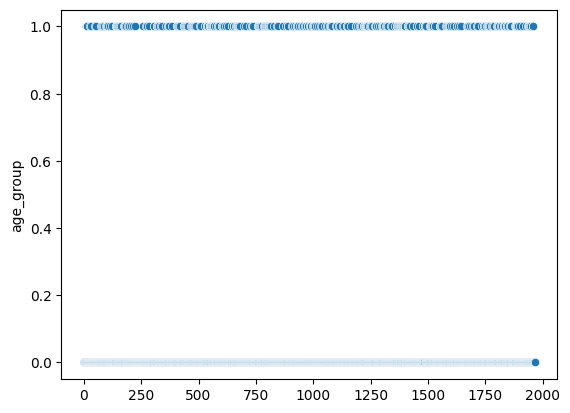

In [26]:
sns.scatterplot(data=y_train)

In [27]:
from sklearn.preprocessing import RobustScaler
X_train_features = X_train.drop(columns=['SEQN'])
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

In [28]:
X_train_features.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,2.0,2.0,35.7,110.0,2.000000,150.0,14.91
1,2.0,2.0,20.3,89.0,2.000000,80.0,3.85
2,1.0,2.0,23.2,89.0,2.000000,68.0,6.14
3,1.0,2.0,28.9,104.0,2.015914,84.0,16.15
4,2.0,1.0,35.9,103.0,2.000000,81.0,10.92


In [32]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name}:")
    print(f"  Mean: {scores.mean():.4f}")

Logistic Regression:
  Mean: 0.8393
Random Forest:
  Mean: 0.8403
Support Vector Machine:
  Mean: 0.8398
K-Nearest Neighbors:
  Mean: 0.8332


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred_train = rf_model.predict(X_train_scaled)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1652
         1.0       1.00      1.00      1.00       314

    accuracy                           1.00      1966
   macro avg       1.00      1.00      1.00      1966
weighted avg       1.00      1.00      1.00      1966



In [37]:
test_set.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,77017.0,1.0,1.0,32.2,96.0,2.0,135.0,15.11
1,75580.0,2.0,2.0,26.3,100.0,2.0,141.0,15.26
2,73820.0,1.0,2.0,28.6,107.0,2.0,136.0,8.82
3,80489.0,2.0,1.0,22.1,93.0,2.0,111.0,12.13
4,82047.0,1.0,1.0,24.7,91.0,2.0,105.0,3.12


In [38]:
test_set.isnull().mean()*100

SEQN        0.641026
RIAGENDR    0.641026
PAQ605      0.320513
BMXBMI      0.320513
LBXGLU      0.320513
DIQ010      0.320513
LBXGLT      0.641026
LBXIN       0.320513
dtype: float64

In [42]:
cols= [var for var in test_set.columns if test_set[var].isnull().mean()*100 > 0]

In [43]:
for var in cols:
    mean= test_set[var].mean()
    test_set[var]= test_set[var].fillna(mean)

In [44]:
test_set.isnull().mean()*100

SEQN        0.0
RIAGENDR    0.0
PAQ605      0.0
BMXBMI      0.0
LBXGLU      0.0
DIQ010      0.0
LBXGLT      0.0
LBXIN       0.0
dtype: float64

In [45]:
from sklearn.preprocessing import RobustScaler
test_features = test_set.drop(columns=['SEQN'])
scaler = RobustScaler()
test_scaled = scaler.fit_transform(test_features)

In [46]:
test_features.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,1.0,1.0,32.2,96.0,2.0,135.0,15.11
1,2.0,2.0,26.3,100.0,2.0,141.0,15.26
2,1.0,2.0,28.6,107.0,2.0,136.0,8.82
3,2.0,1.0,22.1,93.0,2.0,111.0,12.13
4,1.0,1.0,24.7,91.0,2.0,105.0,3.12
